In [ ]:
from google.colab import drive
import os

# 1. Kết nối (Mount) Google Drive vào Colab
drive.mount('/content/drive')

# 2. Chuyển thư mục làm việc hiện tại vào thư mục dự án của bạn
project_path = '/content/drive/MyDrive/Audio_SR_Project'
if os.path.exists(project_path):
    os.chdir(project_path)
    print("✅ Đã kết nối thành công! Đang làm việc tại:", os.getcwd())
else:
    print("❌ Lỗi: Không tìm thấy thư mục Audio_SR_Music trên Drive của bạn.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Đã kết nối thành công! Đang làm việc tại: /content/drive/MyDrive/Audio_SR_Project


In [ ]:
import torch
import torch.nn as nn

class ResidualBlock(nn.Module):
    def __init__(self):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv1d(64, 64, kernel_size=5, stride=1, padding=2)
        self.Relu1 = nn.ReLU()
        self.conv2 = nn.Conv1d(64, 64, kernel_size=5, stride=1, padding=2)

    def forward(self, x):
        residual = self.conv1(x)
        out = self.Relu1(residual)
        out = self.conv2(out)
        return x + out

class MainNetwork(nn.Module):
    def __init__(self):
        super(MainNetwork, self).__init__()
        self.conv1M = nn.Conv1d(1, 64, kernel_size=15, padding=7)
        self.reluM = nn.ReLU()
        self.residual_block1 = ResidualBlock()
        self.residual_block2 = ResidualBlock()
        self.residual_block3 = ResidualBlock()
        self.residual_block4 = ResidualBlock()
        self.residual_block5 = ResidualBlock()
        self.conv2M = nn.Conv1d(64, 1, kernel_size=7, padding=3)

    def forward(self, x):
        initial_input = x
        out = self.conv1M(x)
        out = self.reluM(out)
        out = self.residual_block1(out)
        out = self.residual_block2(out)
        out = self.residual_block3(out)
        out = self.residual_block4(out)
        out = self.residual_block5(out)
        out = self.conv2M(out)
        return initial_input + out

Execution started | Task: 22050Hz to 44100Hz
Constraint: Skipping first 5s, then processing next 20s
Input loaded: drums.wav | Actual duration: 20.00s

1. SNR metric (Time-domain Energy):
   Input (Blurry):   14.76 dB
   Restored (AI):    14.94 dB
   Improvement:      +0.17 dB

2. LSD metric (Frequency Sharpness):
   Input (Blurry):   30.26
   Restored (AI):    27.80
   Improvement:      +2.46

Test complete | Result saved in: Test_Runs/run_20260420_051934


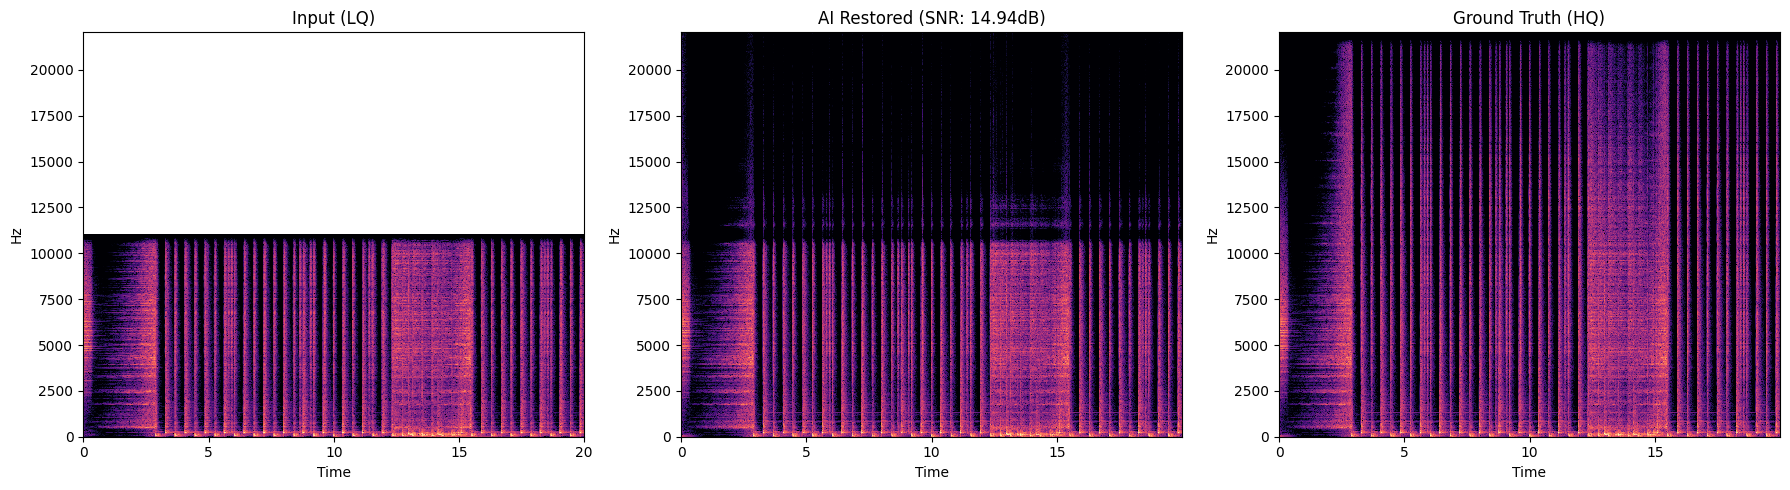

In [ ]:
import os
import time
import torch
import torchaudio
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
from datetime import datetime

# Configuration constants
TARGET_SR = 22050
HIGH_SR = 44100
BIT_DEPTH = 16
MAX_DURATION = 20

def calculate_snr(target, predicted):
    """Compute Signal-to-Noise Ratio with amplitude normalization."""
    min_len = min(len(target), len(predicted))
    target = target[:min_len]
    predicted = predicted[:min_len]

    t_norm = target / (np.max(np.abs(target)) + 1e-8)
    p_norm = predicted / (np.max(np.abs(predicted)) + 1e-8)

    noise = t_norm - p_norm
    sig_pwr = np.sum(t_norm ** 2)
    noise_pwr = np.sum(noise ** 2)

    return 10 * np.log10(sig_pwr / (noise_pwr + 1e-8))

def calculate_lsd(target, predicted):
    """Compute Log Spectral Distance (Lower is better)."""
    n_fft = 2048
    hop_length = 512
    min_len = min(len(target), len(predicted))
    target = target[:min_len]
    predicted = predicted[:min_len]

    S_target = np.abs(librosa.stft(target, n_fft=n_fft, hop_length=hop_length))
    S_pred = np.abs(librosa.stft(predicted, n_fft=n_fft, hop_length=hop_length))

    log_S_target = 20 * np.log10(S_target + 1e-8)
    log_S_pred = 20 * np.log10(S_pred + 1e-8)

    dist = np.sqrt(np.mean((log_S_target - log_S_pred)**2, axis=0))
    return np.mean(dist)

def run_test(input_path, model_path):
    # Initialize timestamped output directory
    run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
    out_dir = os.path.join("Test_Runs", f"run_{run_id}")
    os.makedirs(out_dir, exist_ok=True)

    print(f"Execution started | Task: {TARGET_SR}Hz to {HIGH_SR}Hz")
    print(f"Constraint: Skipping first 5s, then processing next {MAX_DURATION}s")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 1. Audio Loading (Updated: offset=5.0 to skip first 5s)
    y, sr = librosa.load(input_path, sr=None, offset=5.0, duration=MAX_DURATION)
    print(f"Input loaded: {input_path} | Actual duration: {len(y)/sr:.2f}s")

    # 2. Resampling pipeline
    y_gt = librosa.resample(y=y, orig_sr=sr, target_sr=HIGH_SR)
    y_lq = librosa.resample(y=y_gt, orig_sr=HIGH_SR, target_sr=TARGET_SR)

    # 3. Model initialization
    model = MainNetwork().to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # 4. Neural inference
    lq_tensor = torch.from_numpy(y_lq).unsqueeze(0).unsqueeze(0).to(device)
    upsampler = torchaudio.transforms.Resample(TARGET_SR, HIGH_SR).to(device)
    lq_input = upsampler(lq_tensor)
    y_blur = lq_input.squeeze().cpu().numpy()

    start_t = time.time()
    with torch.no_grad():
        out = model(lq_input)
    latency = time.time() - start_t

    y_ai = out.squeeze().cpu().numpy()

    # 5. Quantitative Evaluation
    snr_input = calculate_snr(y_gt, y_blur)
    snr_ai = calculate_snr(y_gt, y_ai)
    lsd_input = calculate_lsd(y_gt, y_blur)
    lsd_ai = calculate_lsd(y_gt, y_ai)

    # Print and Save metrics
    print(f"\n1. SNR metric (Time-domain Energy):")
    print(f"   Input (Blurry):   {snr_input:.2f} dB")
    print(f"   Restored (AI):    {snr_ai:.2f} dB")
    print(f"   Improvement:      {snr_ai - snr_input:+.2f} dB")

    print(f"\n2. LSD metric (Frequency Sharpness):")
    print(f"   Input (Blurry):   {lsd_input:.2f}")
    print(f"   Restored (AI):    {lsd_ai:.2f}")
    print(f"   Improvement:      {lsd_input - lsd_ai:+.2f}")

    # PREPARE DETAILED METRICS CONTENT
    metrics_content = (
        f"1. SNR metric (Time-domain Energy):\n"
        f"   Input (Blurry):   {snr_input:>7.2f} dB\n"
        f"   Restored (AI):    {snr_ai:>7.2f} dB\n"
        f"   Improvement:      {snr_ai - snr_input:>+7.2f} dB\n\n"

        f"2. LSD metric (Frequency Sharpness):\n"
        f"   Input (Blurry):   {lsd_input:>7.2f}\n"
        f"   Restored (AI):    {lsd_ai:>7.2f}\n"
        f"   Improvement:      {lsd_input - lsd_ai:>+7.2f} (lower is better)\n\n"

        f"Inference Details:\n"
        f"   Latency:          {latency:.4f}s\n"
        f"   Device:           {device}\n"
        f"   Run ID:           {run_id}\n"
    )

    with open(os.path.join(out_dir, "metrics.txt"), "w", encoding="utf-8") as f:
        f.write(metrics_content)

    # 6. Visualization
    plt.figure(figsize=(18, 5))
    titles = ['Input (LQ)', f'AI Restored (SNR: {snr_ai:.2f}dB)', 'Ground Truth (HQ)']
    data = [y_lq, y_ai, y_gt]
    srs = [TARGET_SR, HIGH_SR, HIGH_SR]

    for i in range(3):
        plt.subplot(1, 3, i+1)
        stft = librosa.amplitude_to_db(np.abs(librosa.stft(data[i])), ref=np.max)
        librosa.display.specshow(stft, sr=srs[i], x_axis='time', y_axis='hz')
        plt.title(titles[i])
        plt.ylim(0, HIGH_SR // 2)

    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "spectrograms.png"))

    # 7. Export files (Updated: Added ground_truth.wav)
    sf.write(os.path.join(out_dir, "output_ai.wav"), y_ai, HIGH_SR)
    sf.write(os.path.join(out_dir, "input_lq.wav"), y_lq, TARGET_SR)
    sf.write(os.path.join(out_dir, "ground_truth_hq.wav"), y_gt, HIGH_SR)

    print(f"\nTest complete | Result saved in: {out_dir}")

if __name__ == "__main__":
    run_test("drums.wav", "best_music_model.pth")